Começamos criando a Spark Session

In [2]:
from pyspark.sql import SparkSession
spark = SparkSession.builder.appName('AC2-BigData').getOrCreate()

Após isso o dataset será convertido inteiramente para parquet visando a otimização de queries.

In [9]:
import os
base_url = '/home/jovyan/work'
input_path = f"{base_url}/data"
output_path = f"{base_url}/data_parquet"

files = [f for f in os.listdir(input_path) if f.endswith('.csv')]

for file in files:
    table_name = file.replace(".csv", "")
    print(f"Convertendo {table_name}...")

    # Lê o CSV
    df = spark.read.format("csv") \
        .option("header", "True") \
        .option("inferSchema", "True") \
        .load(os.path.join(input_path, file))

    df.write.mode("overwrite").parquet(os.path.join(output_path, table_name))

Convertendo characters...
Convertendo character_anime_works...
Convertendo character_nicknames...
Convertendo details...
Convertendo favs...
Convertendo person_alternate_names...
Convertendo person_anime_works...
Convertendo person_details...
Convertendo person_voice_works...
Convertendo profiles...
Convertendo ratings...
Convertendo recommendations...
Convertendo stats...


Com o dataset já convertido agora é possível realizar queries com mais eficiência. Porém, antes disso será realizado uma comparação em performance entre o dataset em csv puro e o otimizado para dados colunares em parquet.

In [23]:
import time
import matplotlib.pyplot as plt

# Função para medir o tempo de uma query SQL
def benchmark_format(bench_table, format_type):
    start_time = time.time()

    # 1. Lê o arquivo baseado no formato
    if format_type == "csv":
        # Lendo o CSV original (lento)
        df_bench = spark.read.csv(f"{base_url}/data/{bench_table}.csv", header=True, inferSchema=True)
    else:
        # Lendo o Parquet convertido (rápido)
        df_bench = spark.read.parquet(f"{base_url}/data_parquet/{bench_table}")

    # 2. Registra a view para o Injetor SQL
    df_bench.createOrReplaceTempView(f"temp_{format_type}")

    # 3. Executa uma ação (count força o Spark a ler os dados de fato)
    count = spark.sql(f"SELECT count(*) FROM temp_{format_type}").collect()[0][0]

    end_time = time.time()
    duration = end_time - start_time
    print(f"Tempo [{format_type.upper()}]: {duration:.2f} segundos para {count} registros.")
    return duration

# Executando o teste na tabela de 'ratings' (que é a maior)
tempo_csv = benchmark_format("ratings", "csv")
tempo_parquet = benchmark_format("ratings", "parquet")

Tempo [CSV]: 34.97 segundos para 124298357 registros.
Tempo [PARQUET]: 0.81 segundos para 124298357 registros.


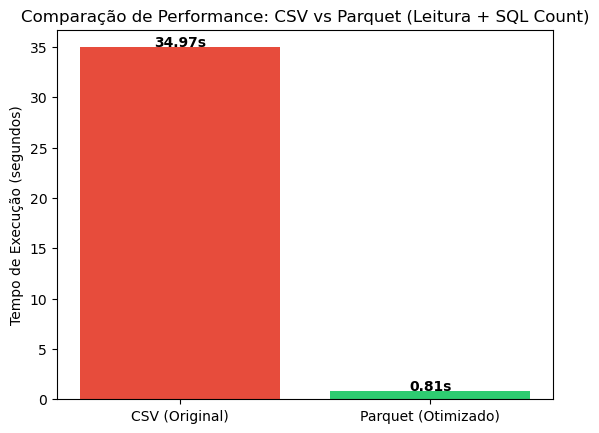

In [24]:
# Dados para o gráfico
formatos = ['CSV (Original)', 'Parquet (Otimizado)']
tempos = [tempo_csv, tempo_parquet]
cores = ['#e74c3c', '#2ecc71'] # Vermelho para lento, Verde para rápido

# Criando o gráfico
plt.bar(formatos, tempos, color=cores)
plt.ylabel('Tempo de Execução (segundos)')
plt.title('Comparação de Performance: CSV vs Parquet (Leitura + SQL Count)')

# Adicionando os valores em cima das barras
for i, v in enumerate(tempos):
    plt.text(i, v + 0.1, f"{v:.2f}s", ha='center', fontweight='bold')

plt.show()

O dataset em CSV puro possui aproximadamente 4.6GB, enquanto o dataset otimizado utilizando Parquet possui 455MB. Uma redução de 90% em tamanho que transmitiu u ganho de performance 43 vezes mais rápido.

In [27]:
parquet_url = f"{base_url}/data_parquet"

ratings_ddl = """
    username STRING,
    anime_id BIGINT,
    status STRING,
    score DOUBLE,
    is_rewatching BOOLEAN,
    num_watched_episodes INT
"""



df_ratings = spark.read.parquet(
    f"{parquet_url}/ratings",
    header=True,
    schema=ratings_ddl
)

df_ratings.createOrReplaceTempView("raw_ratings")

AnalysisException: [PATH_NOT_FOUND] Path does not exist: file:/home/jovyan/data/ratings.csv.